# ***非线性扩散滤波***

In [2]:
import numpy as np#数值计算库
from numpy import random#随机数库

from matplotlib import pyplot as plt#绘图库
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 指定默认字体
plt.rcParams["axes.unicode_minus"] = False  # 解决保存图像是负号'-'显示为方块的问题
import seaborn as sns#高级绘图库
from mpl_toolkits.mplot3d import Axes3D

import pandas as pd#数据处理库

import scipy#信号处理库
from scipy import signal
from scipy.signal import sawtooth
from scipy.signal import hilbert
from scipy.signal import butter, lfilter
from scipy.signal import argrelextrema
from scipy.stats  import kurtosis

import xcw_package as xcw#自定义信号处理库

from CRWU import CRWU_readdata#CRWU数据集
from CRWU import CRWU_CalFCF

# 导入数据

In [11]:
data=CRWU_readdata('DE12K','OR','14','3','6')

该实验转速参数:1723rpm
驱动端DE数据长度:121991
风扇端FE数据长度:121991
基座BA数据长度:121991


In [12]:
CRWU_CalFCF(7.94,39.04,9,1774/60)

{'BPFO': 105.99013831967213,
 'BPFI': 160.1098616803279,
 'BSF': 2.3567477133831605,
 'FTF': 11.776682035519125}

信号长度: 121991
采样频率: 12000.0 Hz
采样间隔: 0.000083 s
信号采样时长: 10.165 s
频谱频率分辨率: 0.098 Hz
可分析频率上限: 6000.0 Hz



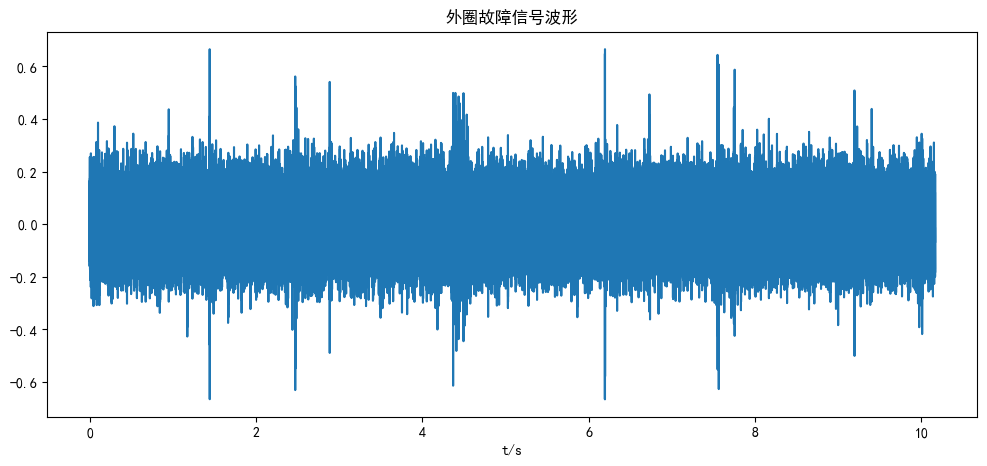

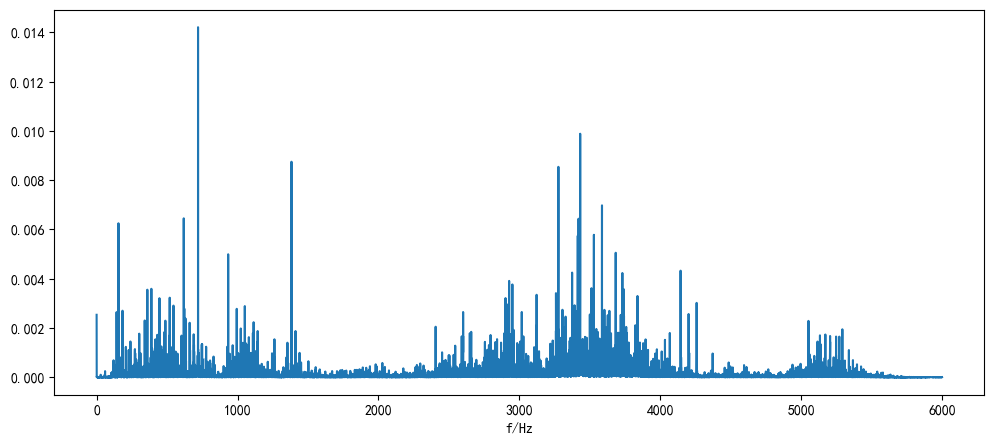

In [13]:
Sig=xcw.Signal(data['DE'],f_s=12000)
Sig.info()
Sig.plot(title='外圈故障信号波形')
xcw.plot_fft(Sig,f_scope=(0,6000))

信号长度: 120000
采样频率: 12000.0 Hz
采样间隔: 0.000083 s
信号采样时长: 10.000 s
频谱频率分辨率: 0.100 Hz
可分析频率上限: 6000.0 Hz



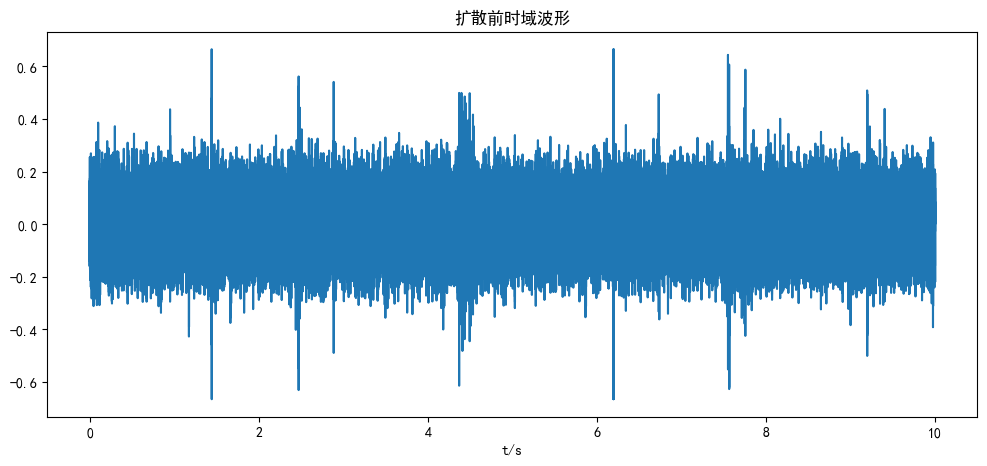

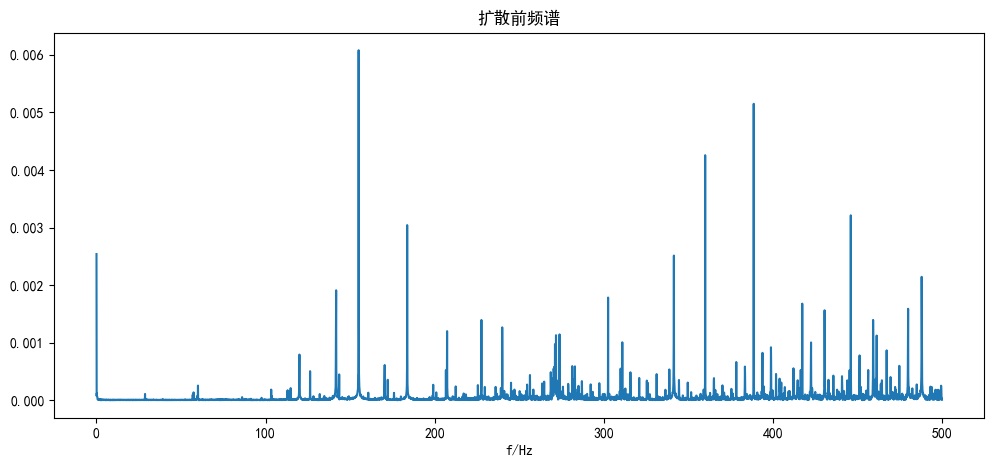

In [16]:
stSig=xcw.resample(Sig,12000,120000)
stSig.info()
stSig.plot(title='扩散前时域波形')
xcw.plot_fft(stSig,f_scope=(0,500),title='扩散前频谱')

# 线性扩散滤波

In [15]:
def Gaussian(x,sigma):#标准高斯函数
    return np.exp(-x**2/(2*sigma**2))/(np.sqrt(2*np.pi)*sigma)

def G(t):#不同尺度高斯核函数，默认扩散系数为0.01
    return lambda x:Gaussian(x,np.sqrt(2*0.0001*t))

def plot_lineardiffusion(s, t,title=None, result=False):
    G_t = G(t)  # 生成高斯核函数
    time=np.arange(0,3*np.sqrt(2*0.0001*t),s.dt)
    time=np.append(-time[::-1],time[1:])#生成时间序列
    g=G_t(time)#生成高斯平滑窗，窗长为6倍标准差，采样率与信号一致
    U_t = signal.convolve(s.data,g, mode='same')#卷积实现扩散
    U_t=U_t*np.mean(s.data)/np.mean(U_t)#归一化
    plt.figure(figsize=(12, 5))
    plt.plot(s.t_values, U_t)
    plt.title(title)
    plt.show()
    print('截止频率:',3/(2*np.pi*np.sqrt(2*0.0001*t)))
    if result:
        return U_t
    else:
        return None

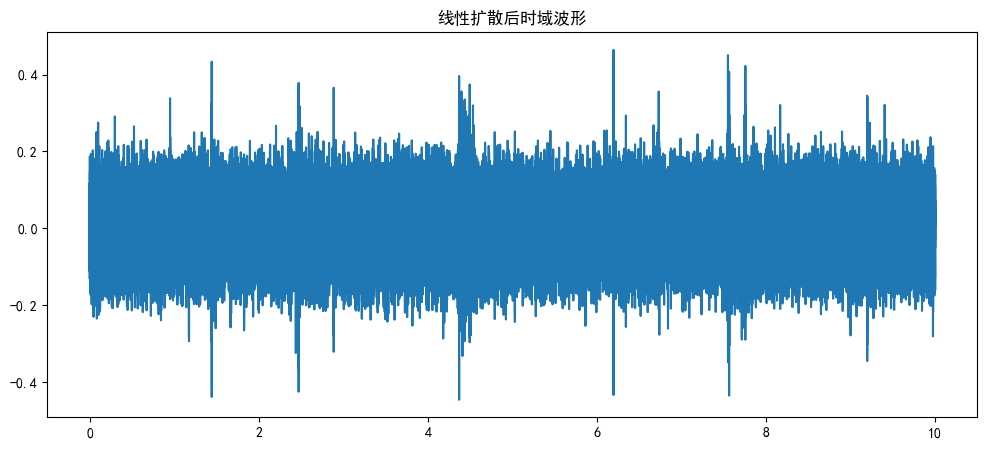

截止频率: 10676.438151257657


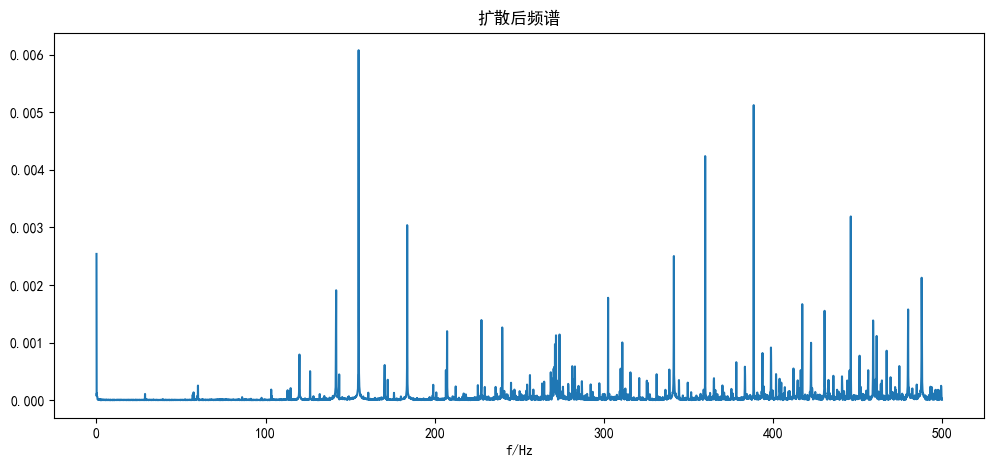

In [20]:
data=plot_lineardiffusion(stSig,0.00001,title='线性扩散后时域波形',result=True)  
dfSig=xcw.Signal(data,f_s=12000)
xcw.plot_fft(dfSig,f_scope=(0,500),title='扩散后频谱')

In [ ]:
itr_T=np.arange(0.00001,0.001,0.00001)
U_t=np.zeros((len(itr_T),stSig.N))
data=stSig.data
for i,t in enumerate(itr_T):
    G_t = G(t)  # 生成高斯核函数

    times=np.arange(0,3*np.sqrt(2*0.0001*t),stSig.dt)
    times=np.append(-times[::-1],times[1:])#生成时间序列

    g=G_t(times)#生成高斯平滑窗，窗长为6倍标准差，采样率与信号一致
    U_t[i] = signal.convolve(data,g, mode='same')#卷积实现扩散
    U_t[i]=U_t[i]*np.mean(data)/np.mean(U_t[i])#归一化


X,Y=np.meshgrid(stSig.t_values,itr_T)
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(X,Y,U_t,cmap='grey',antialiased=True)
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.title('线性扩散过程')
plt.show()

# 非线性扩散滤波

## 各向异性扩散

In [28]:
def diffusion_func1(lam,order=2):#扩散函数1
    return  lambda x: np.exp(-1*(x/lam)**order)

def diffusion_func2(lam):#扩散函数2
    return  lambda x: 1/(1+(x/lam)**2)


def calculate_c(data,dx,dt,diffusion):#根据数据计算扩散系数
    d1=np.gradient(data,dx)#一阶导
    g_t=diffusion(d1)#一阶导作为参数传入扩散函数
    #计算扩散系数
    c_t=np.zeros(len(data)+1)#末尾+1用于迭代计算
    c_t[1:-1] = (g_t[:-1] + g_t[1:]) / 2#c[i]=(g[i]+g[i-1])/2
    c_t[0] = g_t[0]
    c_t[-1] = g_t[-1]#首尾补全
    c_t*=(dt/dx**2*1e-8)#整体缩放确保扩散稳定，步长0.5为最大步长
    return c_t

def plot_nonlineardiffusion(s,iterations,t,lam,title=None,result=False):
    diffusion=diffusion_func2(lam)#选取扩散函数
    data=s.data.copy()
    for i in range(iterations):
        c_t=calculate_c(data,s.dt,t,diffusion)
        _data=data.copy()#在一次迭代中，使用上一次迭代的结果
        for j in range(len(data)):
            if(j==0):
                data[j]=(1-c_t[j]-c_t[j+1])*_data[j]+c_t[j+1]*_data[j+1]#左边界处理
            elif(j==len(data)-1):
                data[j]=c_t[j]*_data[j-1]+(1-c_t[j+1]-c_t[j])*_data[j]#右边界处理
            else:
                data[j]=c_t[j]*_data[j-1]+c_t[j+1]*_data[j+1]+(1-c_t[j+1]-c_t[j])*_data[j]#迭代计算
    plt.figure(figsize=(12, 5))
    plt.plot(s.t_values, data)
    plt.title(title)
    plt.show()
    if result:
        return data
    else:
        return None

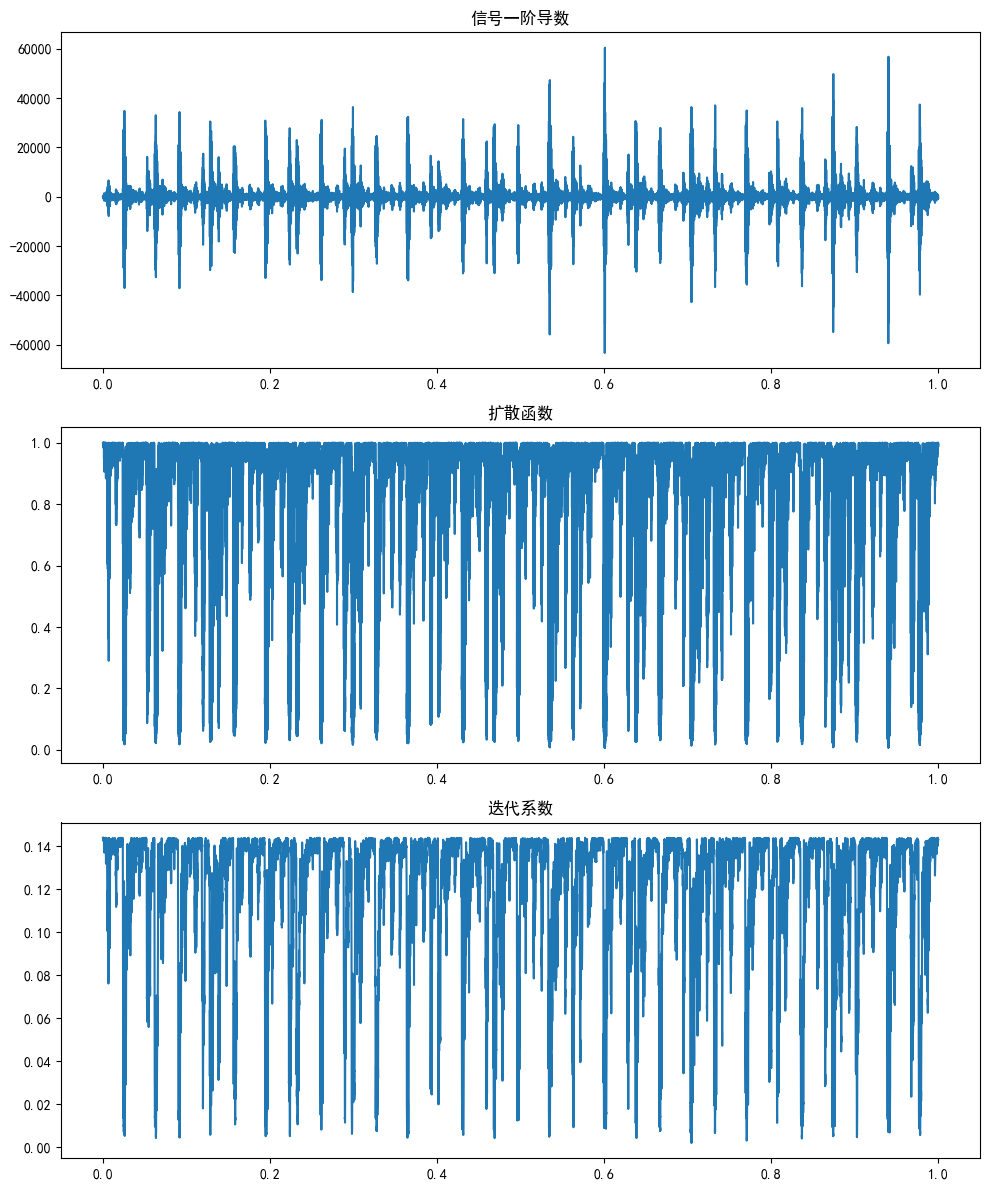

In [18]:
diffusion=diffusion_func2(5000)
d1=np.gradient(stSig.data,stSig.dt)
g=diffusion(d1)
c=calculate_c(stSig.data,stSig.dt,0.1,diffusion)

plt.figure(figsize=(10, 12))

plt.subplot(311)
plt.plot(stSig.t_values,d1)
plt.title('信号一阶导数')

plt.subplot(312)
plt.plot(stSig.t_values,g)
plt.title('扩散函数')

plt.subplot(313)
plt.plot(stSig.t_values,c[:-1])
plt.title('迭代系数')

plt.tight_layout()
plt.show()

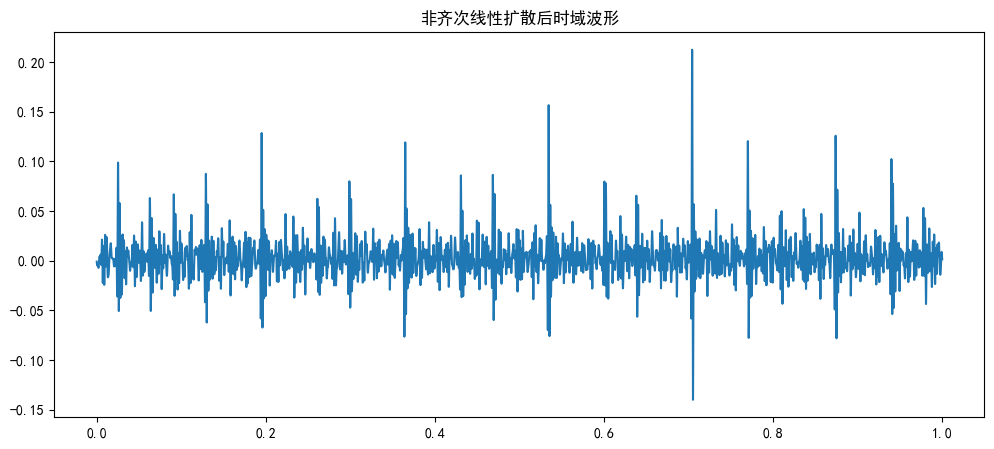

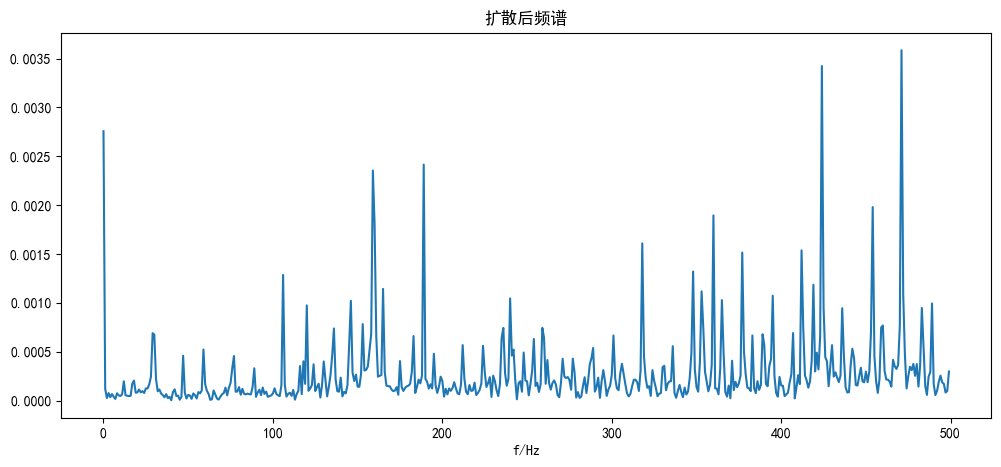

In [29]:
data=plot_nonlineardiffusion(stSig,200,0.1,5000,title='非齐次线性扩散后时域波形',result=True)
dfSig=xcw.Signal(data,f_s=12000)
xcw.plot_fft(dfSig,f_scope=(0,500),title='扩散后频谱')

## 改进数值方法

In [38]:
def g_u(x,dt,lam):#广义扩散函数
    data=np.gradient(x,dt)#信号一阶导作为控制特征
    return (data/lam)*2/(1+(data/lam)**2)#标准化扩散强度衰减函数

def plot_nonlineardiffusion(s,iterations,dt,lam,title=None,result=False):
    data=s.data.copy()
    for i in range(iterations):
        _g=g_u(data,s.dt,lam)#根据最新数据计算扩散系数
        _g=np.gradient(_g,s.dt)*1e-4#中心差分
        data=dt*_g+data#迭代计算,dt=0.1为标准步长
    plt.figure(figsize=(12, 5))
    plt.plot(s.t_values, data)
    plt.xlabel('t/s')
    plt.title(title)
    plt.show()
    if result:
        return data
    else:
        return None

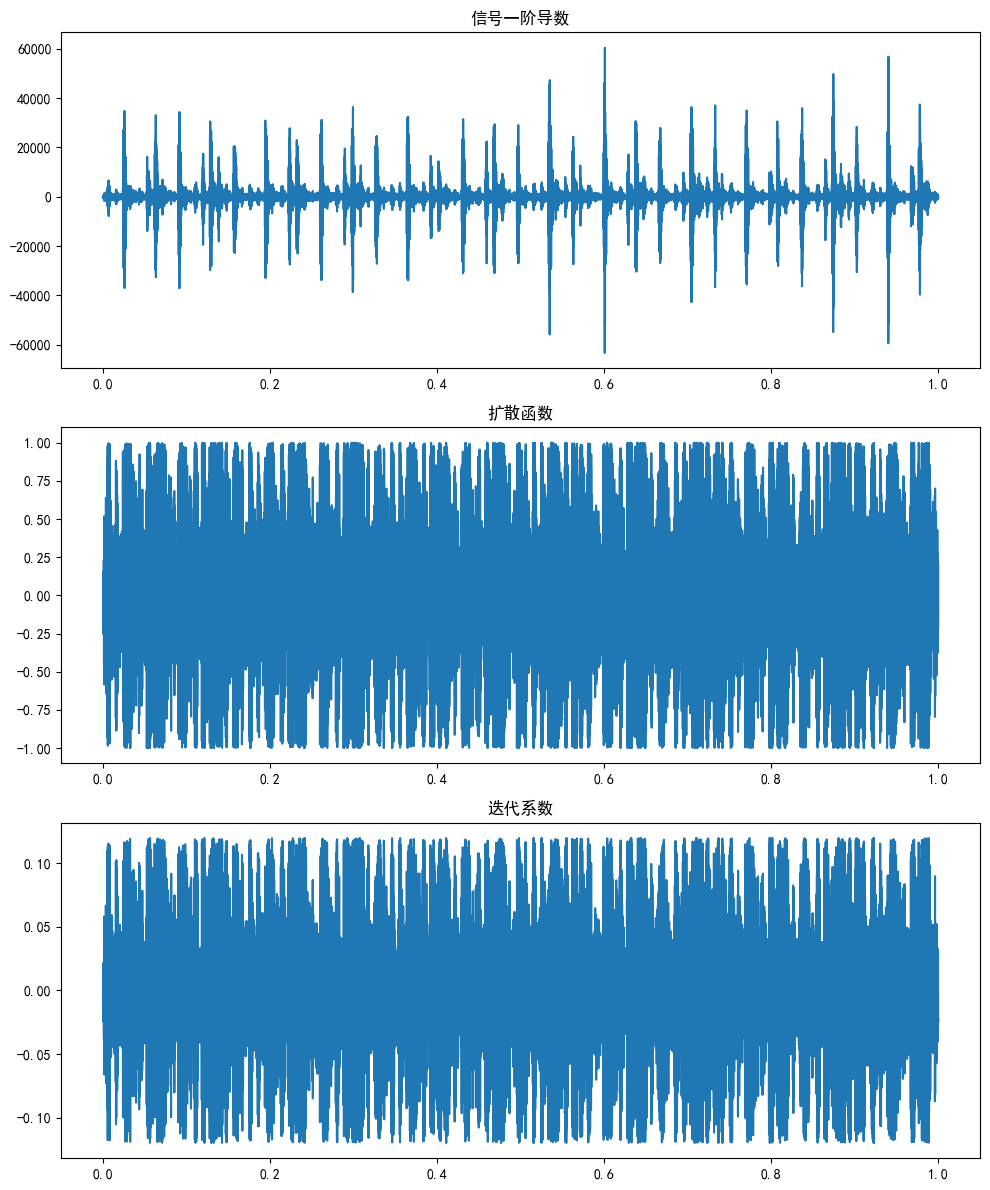

In [24]:
dt=0.1
d1=np.gradient(stSig.data,stSig.dt)
_g=g_u(stSig.data,stSig.dt,5000)
data=(dt*1e-4)*np.gradient(_g,stSig.dt)



plt.figure(figsize=(10, 12))

plt.subplot(311)
plt.plot(stSig.t_values,d1)
plt.title('信号一阶导数')

plt.subplot(312)
plt.plot(stSig.t_values,_g)
plt.title('扩散函数')

plt.subplot(313)
plt.plot(stSig.t_values,data)
plt.title('迭代系数')

plt.tight_layout()
plt.show()

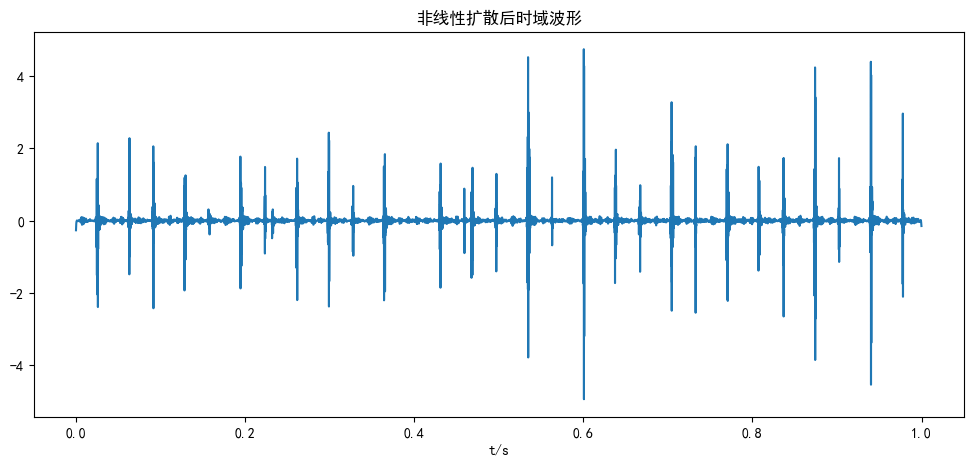

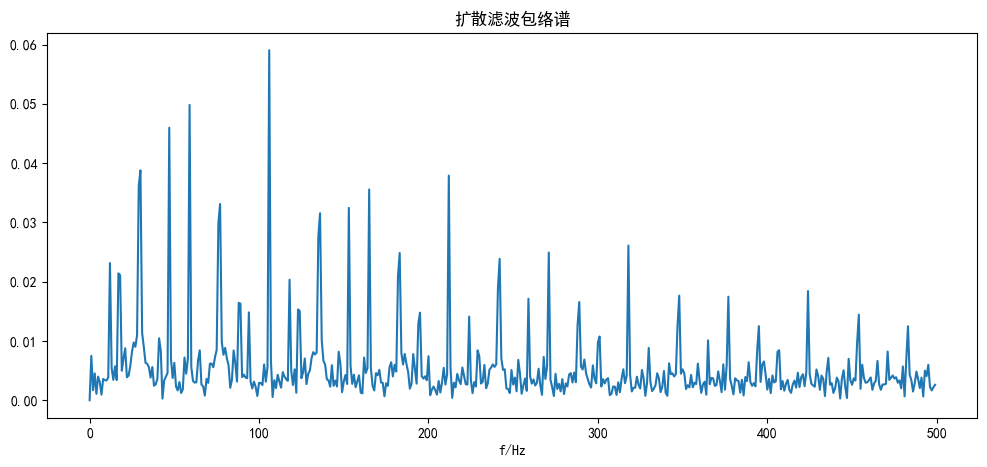

In [39]:
data=plot_nonlineardiffusion(stSig,20,0.1,5000,title='非线性扩散后时域波形',result=True)
dfSig=xcw.Signal(data,f_s=12000)
xcw.plot_Hilbertenvelope(dfSig,f_scope=(0,500),title='扩散滤波包络谱')

In [ ]:
dt=0.1
d1=np.gradient(dfSig.data,dfSig.dt)
_g=g_u(dfSig.data,dfSig.dt,1000)
data=np.gradient(_g,dfSig.dt)*1e-4*dt


plt.figure(figsize=(10, 12))

plt.subplot(311)
plt.plot(dfSig.t_values,d1)
plt.title('信号一阶导数')

plt.subplot(312)
plt.plot(dfSig.t_values,_g)
plt.title('扩散系数')

plt.subplot(313)
plt.plot(dfSig.t_values,data)
plt.title('迭代系数')

plt.tight_layout()
plt.show()

## 改进扩散方法_1

In [ ]:
def g_u(x,w,lam):
    if w%2==0:
        raise ValueError('窗口大小必须为奇数')
    data=np.pad(x,w//2,mode='constant',constant_values=(x[0],x[-1]))#边界填充
    data=pd.Series(data).rolling(window=w,center=True).std()#滑动窗口计算标准差
    data=data[w//2:-w//2+1]#去除边界
    return (data/lam)*2/(1+(data/lam)**2)

def plot_nonlineardiffusion(s,iterations,dt,lam,title=None,result=False):
    data=s.data.copy()
    for i in range(iterations):
        _g=g_u(data,201,lam)#根据最新数据计算扩散系数
        _g=np.gradient(_g,s.dt)*1e-3#中心差分
        data=dt*_g+data#迭代计算,dt=0.1为标准步长
    plt.figure(figsize=(12, 5))
    plt.plot(s.t_values, data)
    plt.title(title)
    plt.show()
    if result:
        return data
    else:
        return None

In [ ]:
lam=1
dt=0.1
window_size=201
x=stSig.data.copy()
x=np.pad(x,window_size//2,mode='constant',constant_values=(x[0],x[-1]))#边界填充
x=pd.Series(x).rolling(window=window_size,center=True).std()#滑动窗口计算标准差
x=x[window_size//2:-window_size//2+1]#去除边界
_g=g_u(stSig.data,window_size,lam)
data=np.gradient(_g,stSig.dt)*1e-3*dt

plt.figure(figsize=(10, 12))

plt.subplot(311)
plt.plot(dfSig.t_values,x)
plt.title('信号标准差')

plt.subplot(312)
plt.plot(dfSig.t_values,_g)
plt.title('扩散系数')

plt.subplot(313)
plt.plot(dfSig.t_values,data)
plt.title('迭代系数')

plt.tight_layout()
plt.show()

In [ ]:
data=plot_nonlineardiffusion(stSig,200,0.1,1,title='扩散滤波',result=True)
sdSig=xcw.Signal(data,f_s=12000)
xcw.plot_Hilbertenvelope(sdSig,f_scope=(0,500),title='扩散滤波包络谱')

In [ ]:
lam=1
dt=0.1
window_size=201
x=sdSig.data.copy()
x=np.pad(x,window_size//2,mode='constant',constant_values=(x[0],x[-1]))#边界填充
x=pd.Series(x).rolling(window=window_size,center=True).std()#滑动窗口计算标准差
x=x[window_size//2:-window_size//2+1]#去除边界
_g=g_u(sdSig.data,window_size,lam)
data=np.gradient(_g,sdSig.dt)*1e-3*dt

plt.figure(figsize=(10, 12))

plt.subplot(311)
plt.plot(dfSig.t_values,x)
plt.title('信号标准差')

plt.subplot(312)
plt.plot(dfSig.t_values,_g)
plt.title('扩散系数')

plt.subplot(313)
plt.plot(dfSig.t_values,data)
plt.title('迭代系数')

plt.tight_layout()
plt.show()

### 窗长-阈值超参数测试

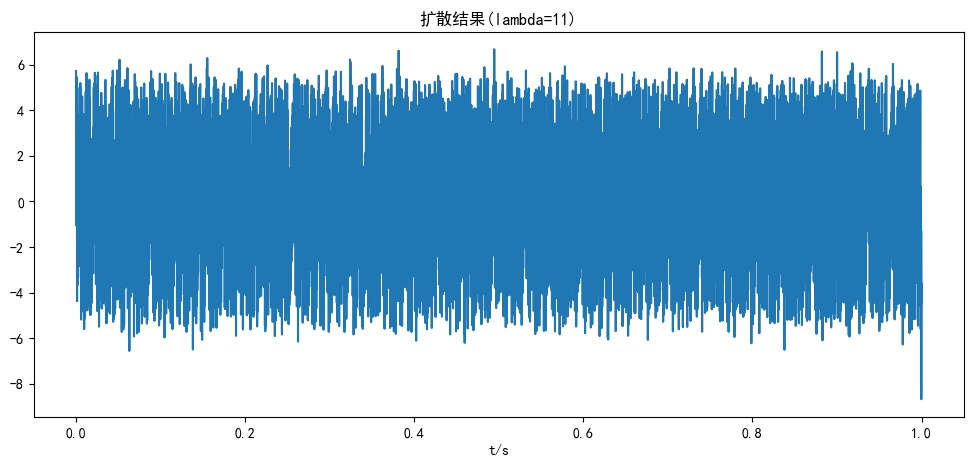

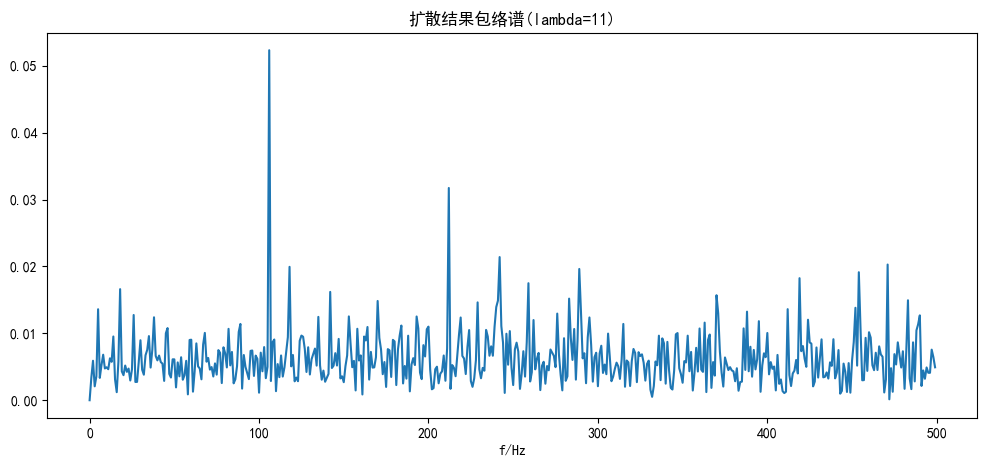

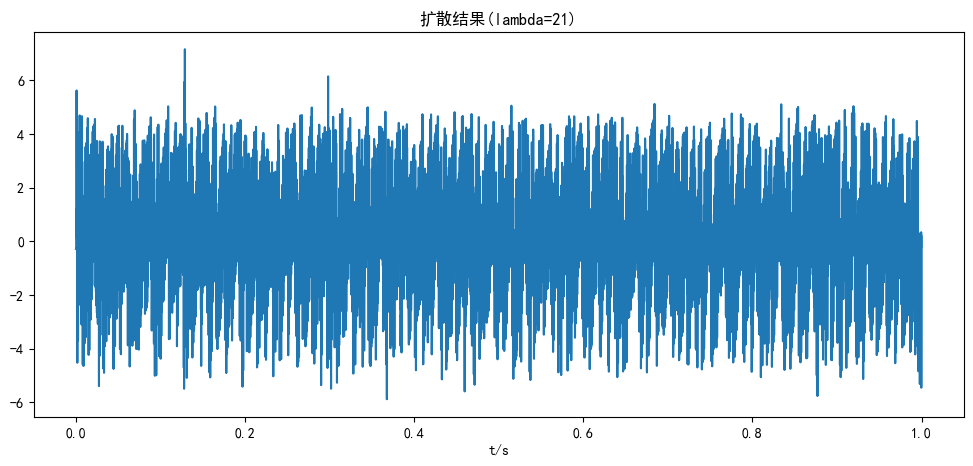

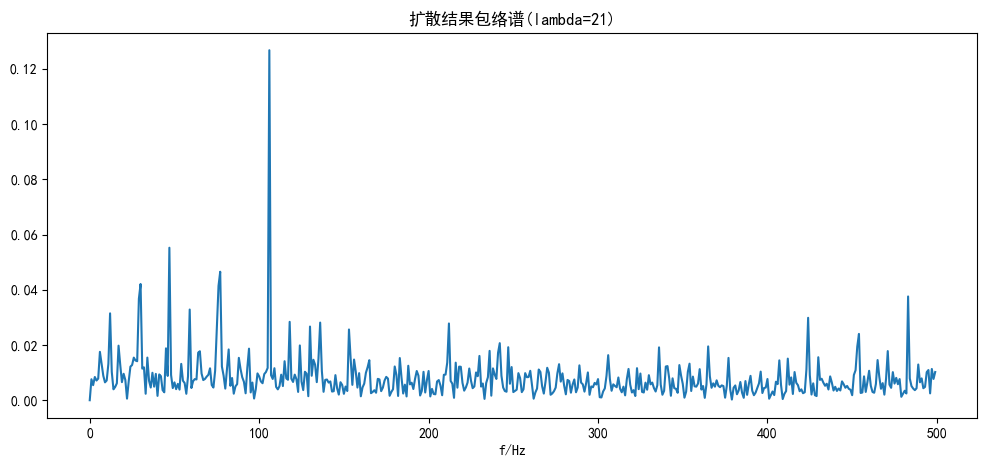

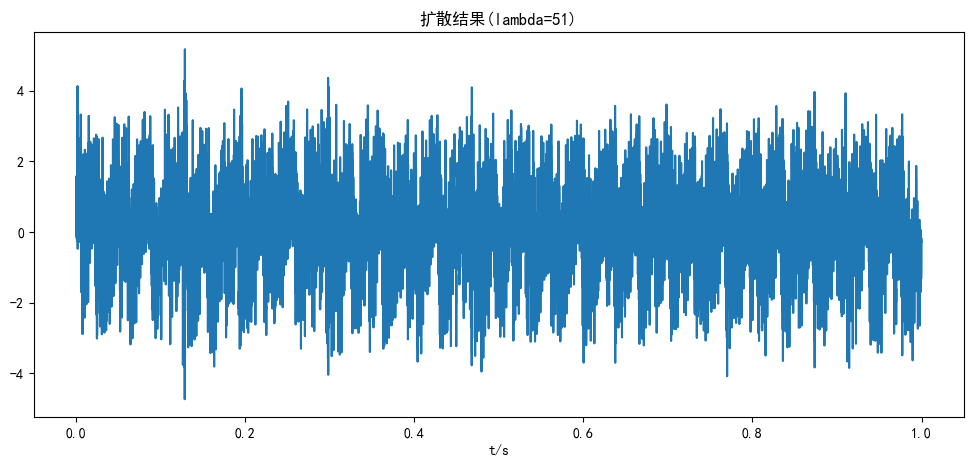

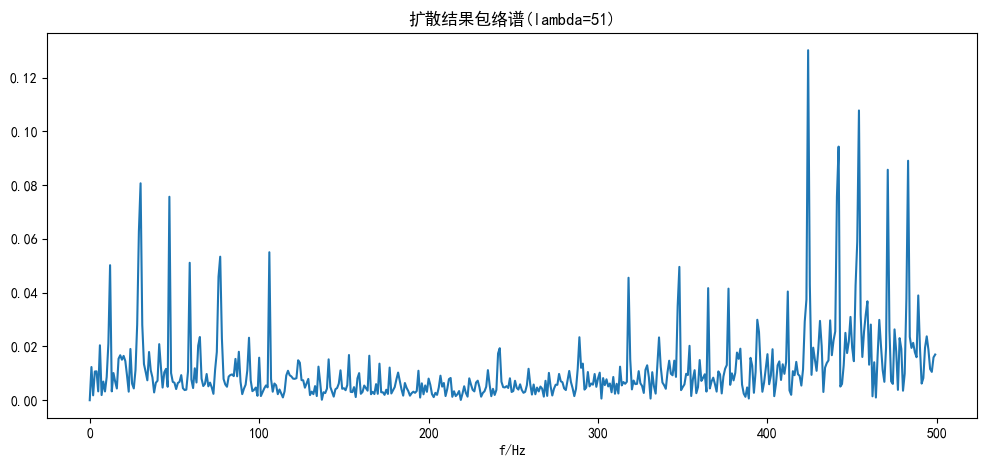

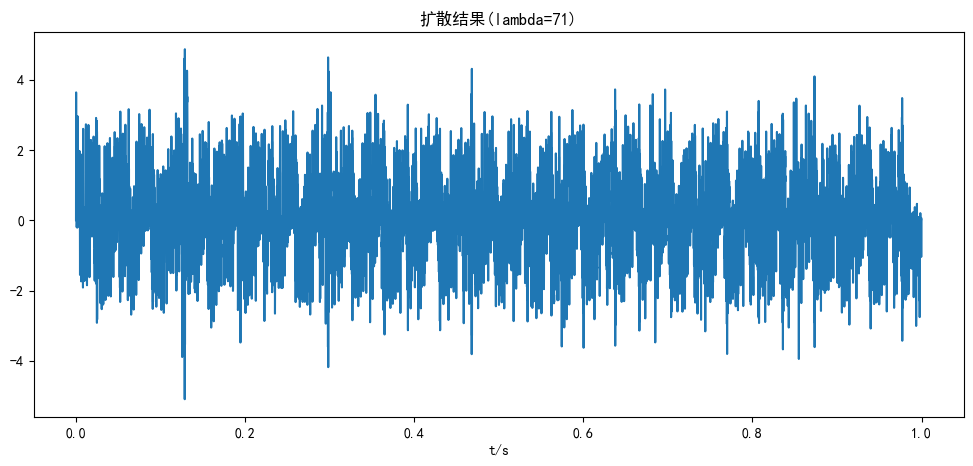

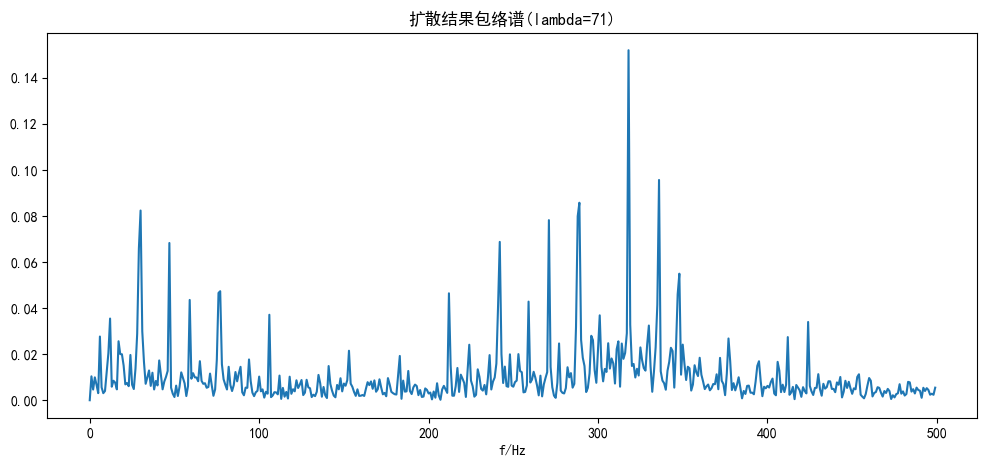

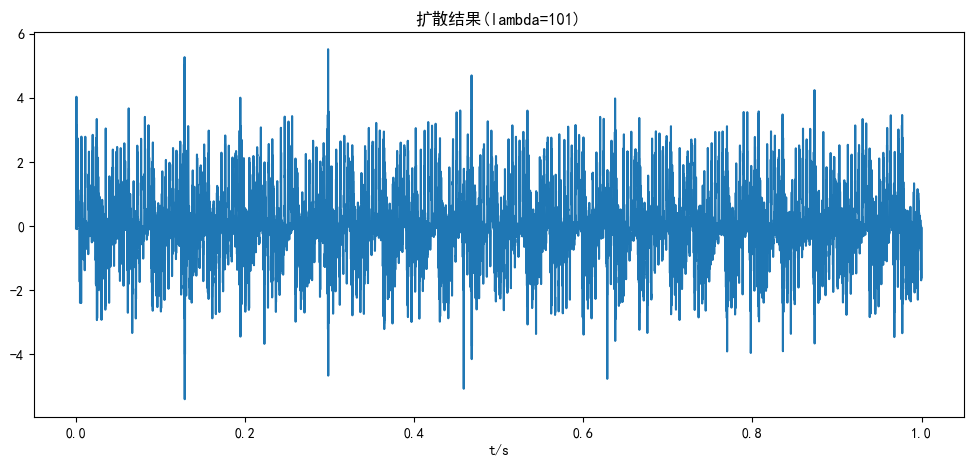

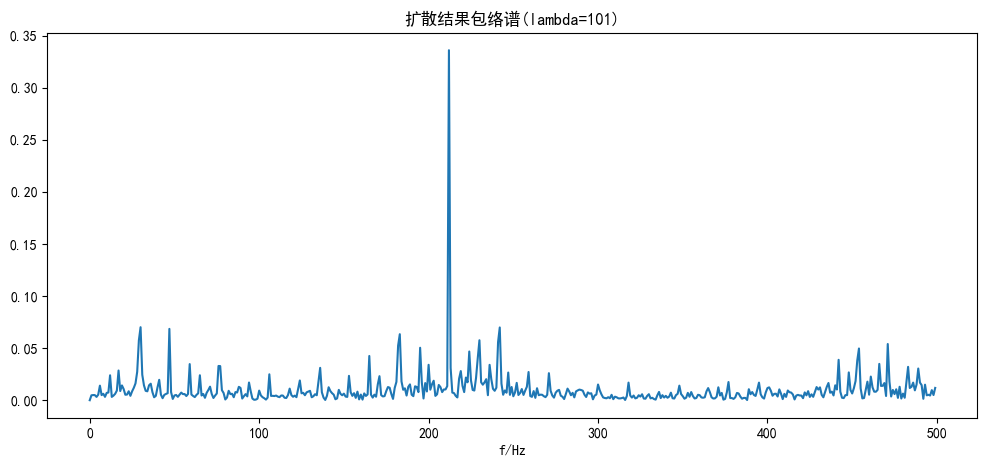

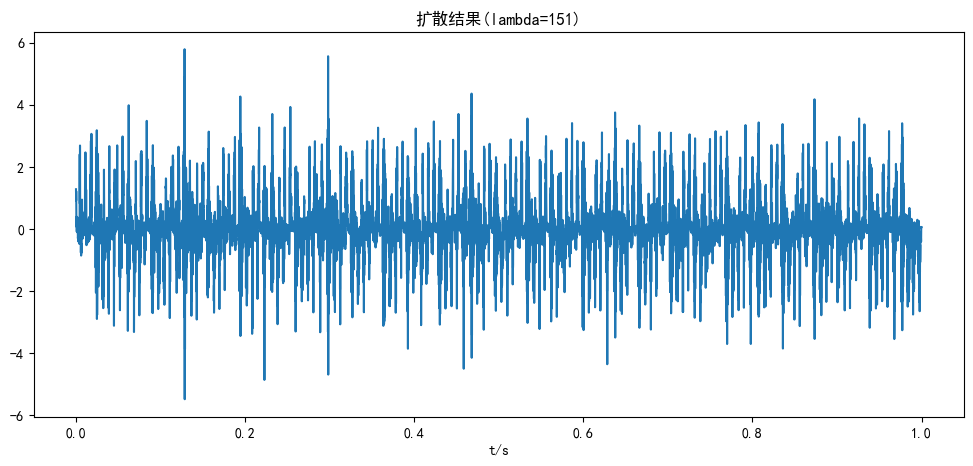

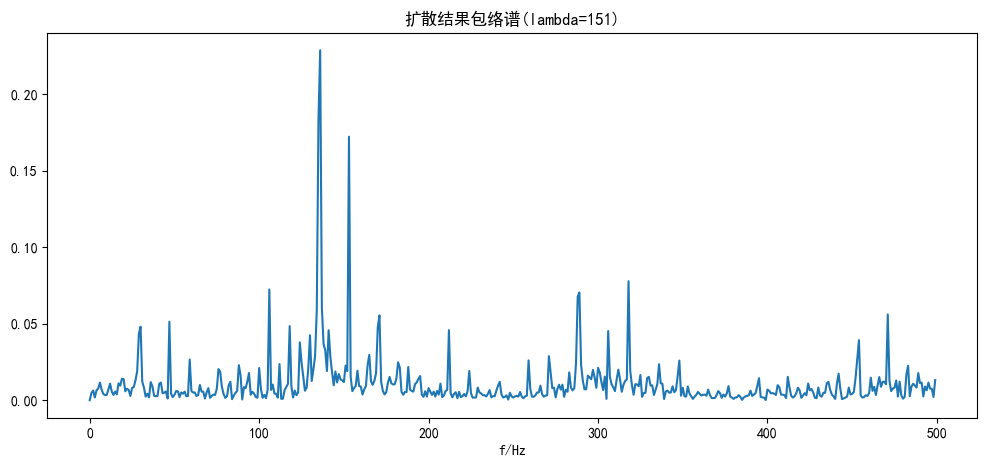

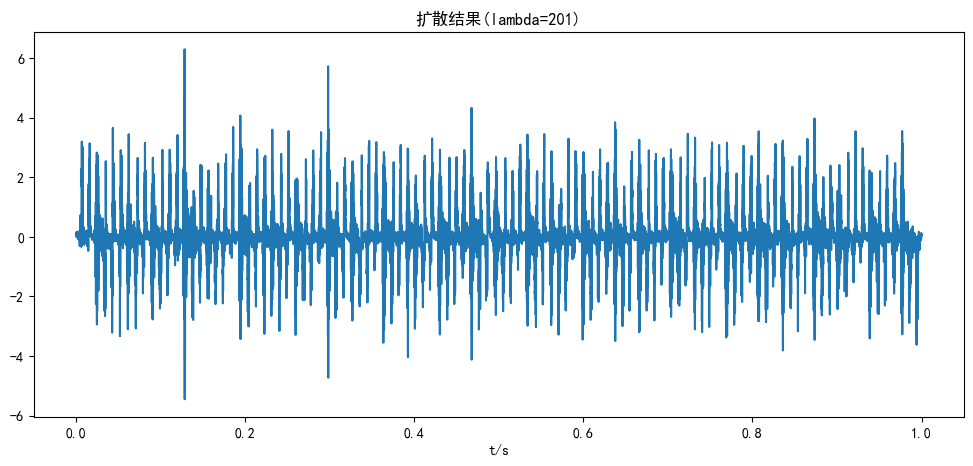

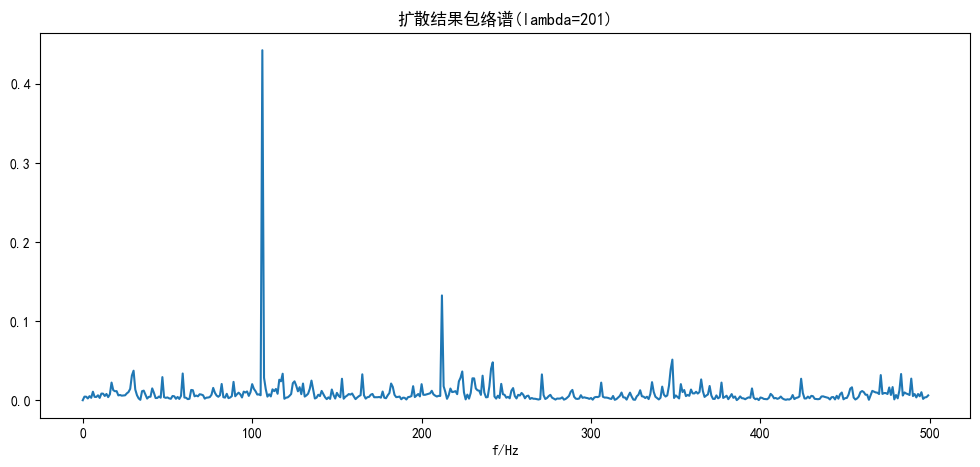

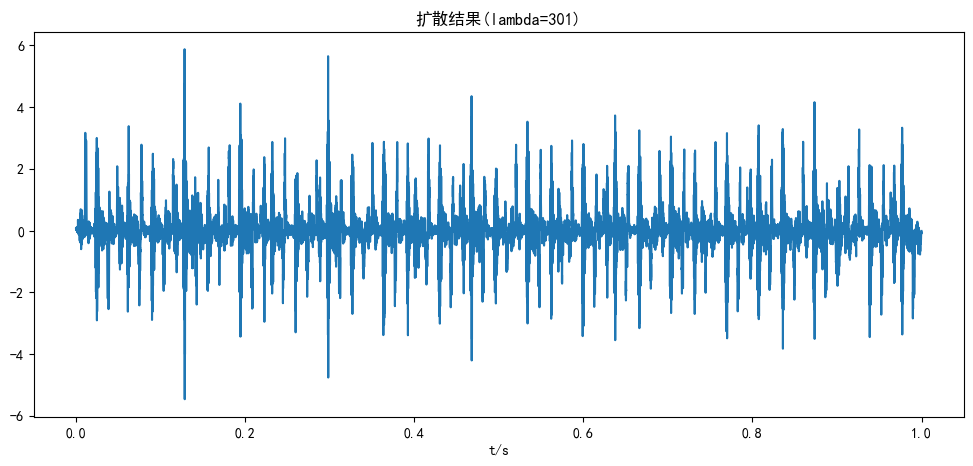

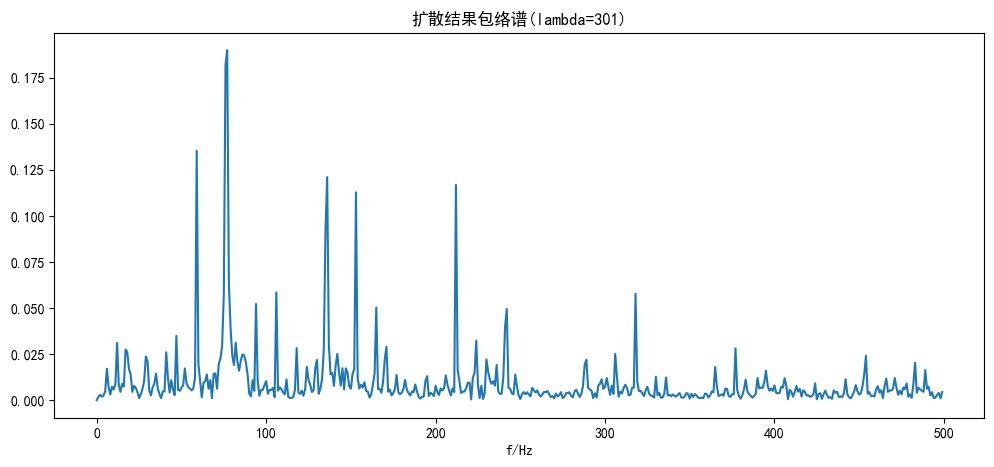

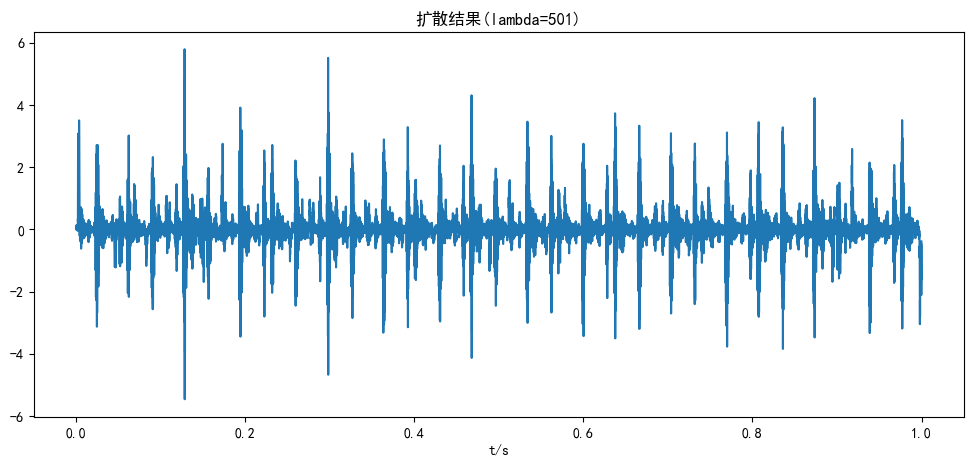

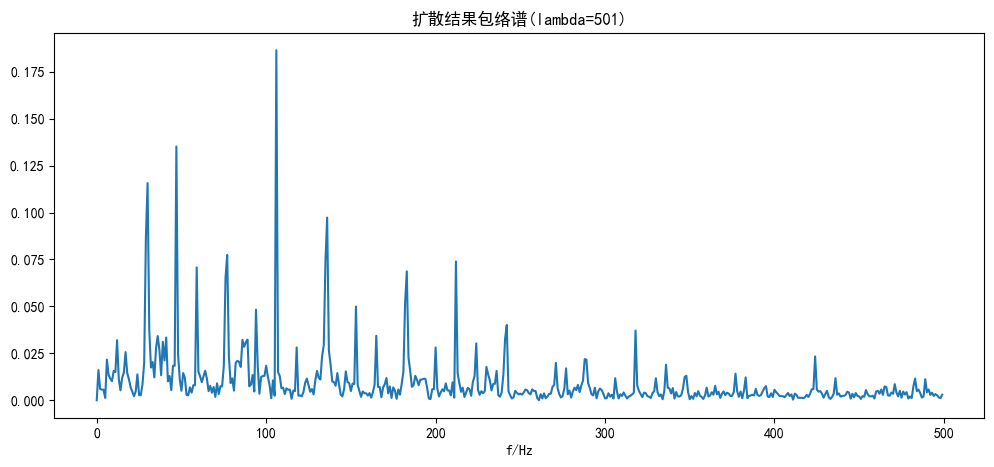

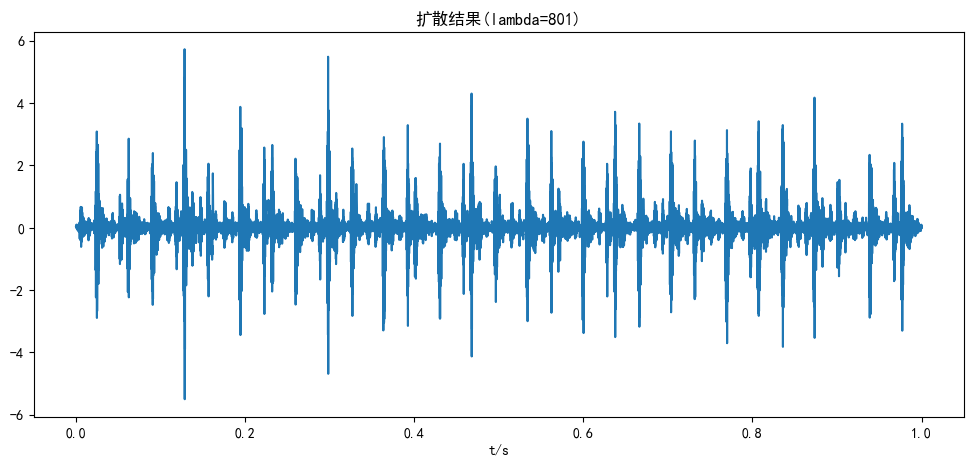

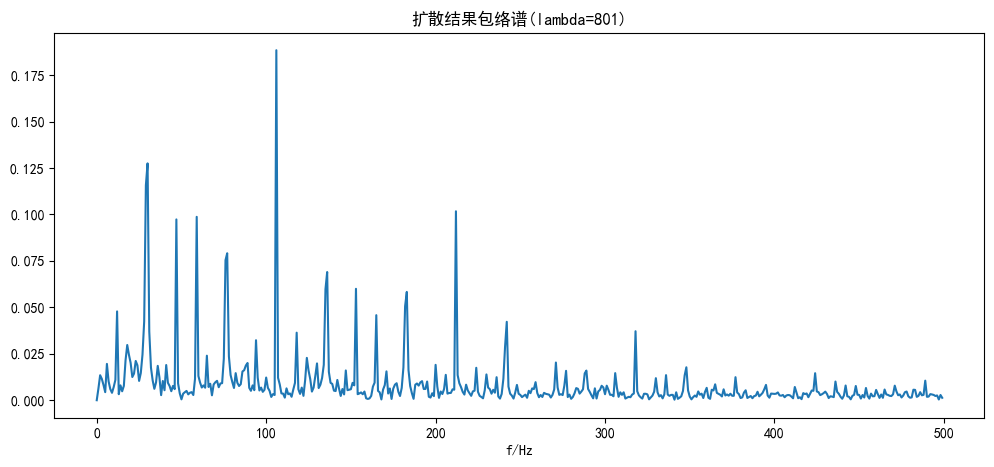

In [ ]:
w_list=[11,21,51,71,101,151,201,301,501,801]
lam_list=[2.5,1.8,1.2,1,1,0.9,0.9,0.7,0.6,0.5]
data=stSig.data.copy()
for i in range(len(w_list)):
    w=w_list[i]
    lam=lam_list[i]
    data=plot_nonlineardiffusion(stSig,iterations=200,dt=0.1,lam=lam,w=w,title=f'扩散结果(lambda={w})',result=True)
    resSig=xcw.Signal(data,f_s=12000)
    xcw.plot_Hilbertenvelope(resSig,f_scope=(0,500),title=f'扩散结果包络谱(lambda={w})')

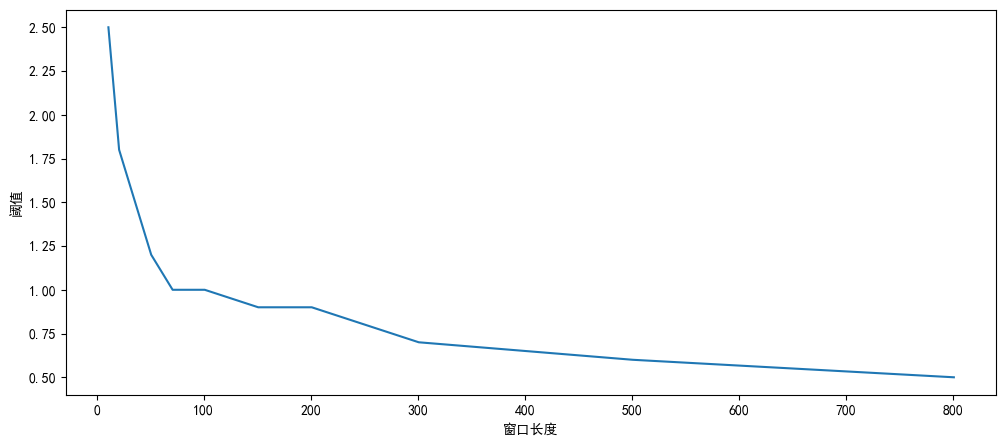

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(w_list,lam_list)
plt.xlabel('窗口长度')
plt.ylabel('阈值')
plt.show()

## 改进扩散方法_2

In [ ]:
def autocorr_kur(x):
    mean=np.mean(x)
    R_x=np.correlate(x-mean,x-mean,mode='full')#自相关函数
    R_x=R_x[:len(x)-1]/R_x[len(x)-1]#取对称的右半部并归一化
    return kurtosis(R_x)#计算自相关函数的峰度

def rolling_window(x, w, step):
    x=np.pad(x, w//2, mode='constant', constant_values=(x[0], x[-1]))  # 边界填充
    center_x=np.arange(w//2,len(x)-w//2,step)#有重叠移动窗口中心
    rolling=np.zeros((len(center_x),w))
    for i,center in enumerate(center_x):
        rolling[i]=x[center-w//2:center+w//2+1]#每隔step取一个窗口，共取len(center_x)个
    return rolling  

def g_u(x,w,s,lam):
    if w%2==0:
        raise ValueError('窗口大小必须为奇数')
    data=rolling_window(x,w,s)#生成重叠移动窗
    data=np.apply_along_axis(autocorr_kur,1,data)#计算每个窗口的自相关峭度
    t_or=np.arange(len(x))
    t_down=np.arange(0,len(x),s)
    data=np.interp(t_or,t_down,data)#插值
    return (data/lam)*2/(1+(data/lam)**2)

def plot_nonlineardiffusion(s,iterations,dt,lam,title=None,result=False):
    data=s.data.copy()
    for i in range(iterations):
        _g=g_u(data,201,20,lam)#根据最新数据计算扩散系数
        _g=np.gradient(_g,s.dt)*1e-3#中心差分
        data=dt*_g+data#迭代计算,dt=0.1为标准步长
    plt.figure(figsize=(12, 5))
    plt.plot(s.t_values, data)
    plt.title(title)
    plt.show()
    if result:
        return data
    else:
        return None

In [ ]:
lam=1
dt=0.1
window_size=51
step=10
x=stSig.data.copy()
x = rolling_window(x, window_size,step)
x=np.apply_along_axis(autocorr_kur,1,x)#计算自相关峭度
t_or=np.arange(stSig.N)
t_down=np.arange(0,stSig.N,step)
x=np.interp(t_or,t_down,x)#插值

_g=g_u(stSig.data,window_size,step,lam)
data=np.gradient(_g,stSig.dt)*1e-3*dt

plt.figure(figsize=(10, 12))

plt.subplot(311)
plt.plot(stSig.t_values,x)
plt.title('信号自相关峭度')

plt.subplot(312)
plt.plot(stSig.t_values,_g)
plt.title('扩散系数')

plt.subplot(313)
plt.plot(stSig.t_values,data)
plt.title('迭代系数')

plt.tight_layout()
plt.show()

In [ ]:
data=plot_nonlineardiffusion(stSig,200,0.05,1,title='扩散滤波',result=True)
rkSig=xcw.Signal(data,f_s=12000)
xcw.plot_Hilbertenvelope(rkSig,f_scope=(0,500),title='扩散滤波包络谱')

## 改进扩散方法_3

In [ ]:
def diffusion(lam):#扩散函数2
    return  lambda x: 1/(1+(x/lam)**2)

def calculate_c(data,dx,dt,w,lam):#根据数据计算扩散系数
    E=np.pad(data,w//2,mode='constant',constant_values=(data[0],data[-1]))#边界填充
    E=pd.Series(E).rolling(window=w,center=True).std()
    E=E[w//2:-w//2+1].values#得到信号的移动窗标准差
    E=np.square(E)
    g_t=diffusion(lam)(E)#扩散函数
    #计算扩散系数
    c_t=np.zeros(len(data)+1)#末尾+1用于迭代计算
    c_t[0] = g_t[0]
    c_t[-1] = g_t[-1]#首尾补全
    g_t=g_t[1:]+g_t[:-1]#中心差分
    c_t[1:-1] = g_t/ 2#c[i]=(g[i]+g[i-1])/2

    c_t*=(dt/dx**2*1e-8)#整体缩放确保扩散稳定，步长0.5为最大步长
    return c_t

def plot_nonlineardiffusion(s,iterations,t,lam,window_size,title=None,result=False):
    data=s.data.copy()
    for i in range(iterations):
        c_t=calculate_c(data,s.dt,t,window_size,lam)
        _data=data.copy()#在一次迭代中，使用上一次迭代的结果
        for j in range(len(data)):
            if(j==0):
                data[j]=(1-c_t[j]-c_t[j+1])*_data[j]+c_t[j+1]*_data[j+1]#左边界处理
            elif(j==len(data)-1):
                data[j]=c_t[j]*_data[j-1]+(1-c_t[j+1]-c_t[j])*_data[j]#右边界处理
            else:
                data[j]=c_t[j]*_data[j-1]+c_t[j+1]*_data[j+1]+(1-c_t[j+1]-c_t[j])*_data[j]#迭代计算
    plt.figure(figsize=(12, 5))
    plt.plot(s.t_values, data)
    plt.title(title)
    plt.show()
    if result:
        return data
    else:
        return None

In [ ]:
data=stSig.data.copy()
w=201
lam=0.1
E=np.pad(data,w//2,mode='constant',constant_values=(data[0],data[-1]))#边界填充
E=pd.Series(E).rolling(window=w,center=True).std()
E=E[w//2:-w//2+1].values#得到信号的移动窗标准差
E=np.square(E)#方差
g=diffusion(lam)(E)
c=calculate_c(data,stSig.dt,0.1,w,lam)

plt.figure(figsize=(10, 12))

plt.subplot(311)
plt.plot(stSig.t_values,E)
plt.title('信号移动标准差')

plt.subplot(312)
plt.plot(stSig.t_values,g)
plt.title('扩散函数')

plt.subplot(313)
plt.plot(stSig.t_values,c[:-1])
plt.title('迭代系数')

plt.tight_layout()
plt.show()

In [ ]:
data=plot_nonlineardiffusion(stSig,200,0.1,0.1,51,title='扩散滤波',result=True)
sdSig=xcw.Signal(data,f_s=12000)
xcw.plot_Hilbertenvelope(sdSig,f_scope=(0,500),title='扩散滤波包络谱')

## 改进扩散方法_4

In [124]:
def diffusion(lam):#扩散函数2
    return  lambda x: 1/(1+(x/lam)**2)

def autocorr_kur(x):
    mean=np.mean(x)
    R_x=np.correlate(x-mean,x-mean,mode='full')#自相关函数
    R_x=R_x[:len(x)-1]/R_x[len(x)-1]#取对称的右半部并归一化
    return kurtosis(R_x)#计算自相关函数的峰度

def rolling_window(x, w, step):
    data=np.pad(x, w//2, mode='constant', constant_values=(x[0], x[-1]))  # 边界填充
    center_x=np.arange(w//2,len(data)-w//2,step)#有重叠移动窗口中心
    rolling=np.zeros((len(center_x),w))
    for i,center in enumerate(center_x):
        rolling[i]=data[center-w//2:center+w//2+1]#每隔step取一个窗口，共取len(center_x)个
    return rolling  

def calculate_c(data,dx,dt,w,step,lam):#根据数据计算扩散系数
    if w%2==0:
        raise ValueError('窗口大小必须为奇数')
    E=rolling_window(data,w,step)#生成重叠移动窗
    E=np.apply_along_axis(autocorr_kur,1,E)#计算每个窗口的自相关峭度
    t_or=np.arange(len(data))
    t_down=np.arange(0,len(data),step)
    E=np.interp(t_or,t_down,E)#插值
    g_t=diffusion(lam)(E)#扩散函数
    #计算扩散系数
    c_t=np.zeros(len(data)+1)#末尾+1用于迭代计算
    c_t[0] = g_t[0]
    c_t[-1] = g_t[-1]#首尾补全
    g_t=g_t[1:]+g_t[:-1]#中心差分
    c_t[1:-1] = g_t/ 2#c[i]=(g[i]+g[i-1])/2

    c_t*=(dt/dx**2*1e-8)#整体缩放确保扩散稳定，步长0.5为最大步长
    return c_t

def plot_nonlineardiffusion(s,iterations,t,lam,window_size,step,title=None,result=False):
    data=s.data.copy()
    for i in range(iterations):
        c_t=calculate_c(data,s.dt,t,window_size,step,lam)
        _data=data.copy()#在一次迭代中，使用上一次迭代的结果
        for j in range(len(data)):
            if(j==0):
                data[j]=(1-c_t[j]-c_t[j+1])*_data[j]+c_t[j+1]*_data[j+1]#左边界处理
            elif(j==len(data)-1):
                data[j]=c_t[j]*_data[j-1]+(1-c_t[j+1]-c_t[j])*_data[j]#右边界处理
            else:
                data[j]=c_t[j]*_data[j-1]+c_t[j+1]*_data[j+1]+(1-c_t[j+1]-c_t[j])*_data[j]#迭代计算
    plt.figure(figsize=(12, 5))
    plt.plot(s.t_values, data)
    plt.title(title)
    plt.show()
    if result:
        return data
    else:
        return None

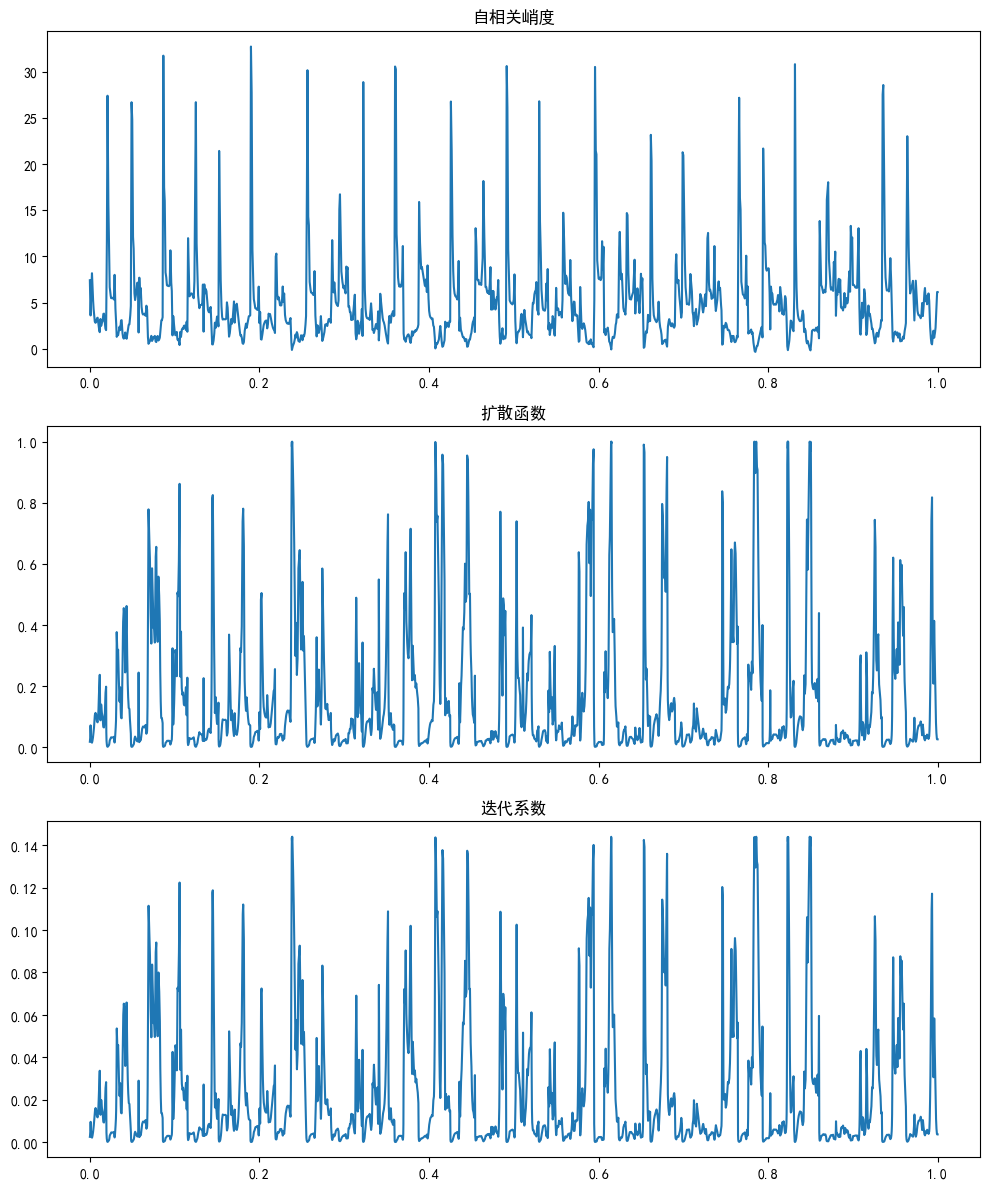

In [133]:
data=stSig.data.copy()
w=101
step=10
lam=1
E=rolling_window(data,w,step)#生成重叠移动窗
E=np.apply_along_axis(autocorr_kur,1,E)#计算每个窗口的自相关峭度
t_or=np.arange(stSig.N)
t_down=np.arange(0,stSig.N,step)
E=np.interp(t_or,t_down,E)#插值
g=diffusion(lam)(E)
c=calculate_c(data,stSig.dt,0.1,w,step,lam)

plt.figure(figsize=(10, 12))

plt.subplot(311)
plt.plot(stSig.t_values,E)
plt.title('自相关峭度')

plt.subplot(312)
plt.plot(stSig.t_values,g)
plt.title('扩散函数')

plt.subplot(313)
plt.plot(stSig.t_values,c[:-1])
plt.title('迭代系数')

plt.tight_layout()
plt.show()

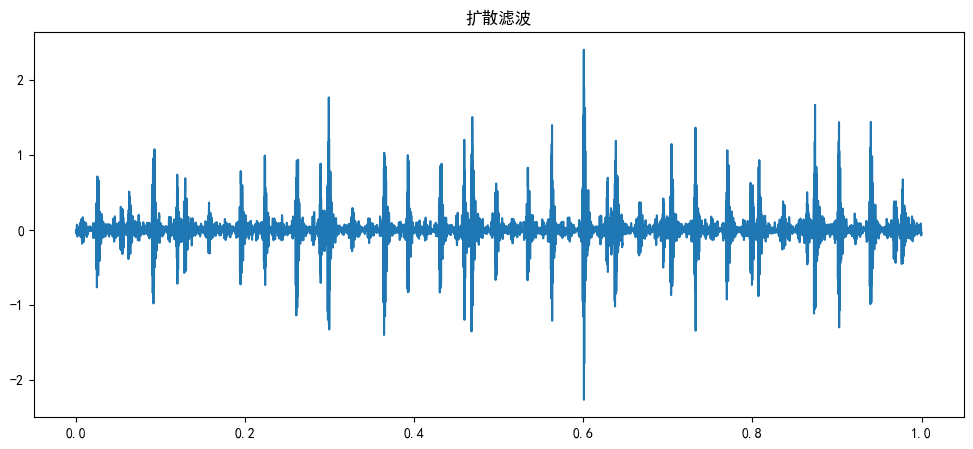

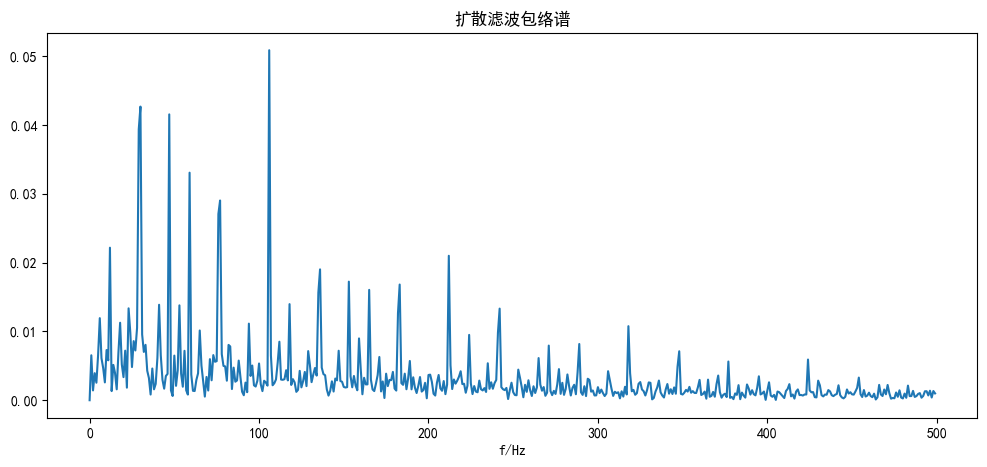

In [134]:
data=plot_nonlineardiffusion(stSig,100,0.1,1,101,10,title='扩散滤波',result=True)
rkSig=xcw.Signal(data,f_s=12000)
xcw.plot_Hilbertenvelope(rkSig,f_scope=(0,500),title='扩散滤波包络谱')